In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("thedatasith/sku110k-annotations")

print("Dataset path:", path)
print("\nFiles:")
print(os.listdir(path))

100%|██████████| 13.2G/13.2G [11:51<00:00, 19.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14

Files:
['README.md', 'data_kaggle.yaml', 'convert_yolov5.ipynb', 'SKU110K_fixed']


In [3]:
from pathlib import Path

dataset_root = Path(path) / "SKU110K_fixed"
yaml_path = Path(path) / "data_kaggle.yaml"

print("Dataset root:", dataset_root)
print("\nDirectory structure:")

for item in sorted(dataset_root.rglob("*")):
    if item.is_dir():
        print(item.relative_to(dataset_root))

print("\nExisting YAML:")
print(yaml_path.read_text())

Dataset root: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed

Directory structure:
images
images/test
images/train
images/val
labels
labels/test
labels/train
labels/val

Existing YAML:
# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: /kaggle/input/sku110k-annotations/SKU110K_fixed/images  # dataset root dir
train: train  # train images (relative to 'path')  8219 images
val: val  # val images (relative to 'path')  588 images
test: test  # test images (optional)  2936 images

# Classes
nc: 1  # number of classes
names: ['object']  # class names


In [4]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png"}

for split in ["train", "val", "test"]:
    image_dir = dataset_root / "images" / split
    label_dir = dataset_root / "labels" / split

    images = [
        file for file in image_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    labels = list(label_dir.glob("*.txt"))

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))

    missing_labels = [
        image.name
        for image in images
        if not (label_dir / f"{image.stem}.txt").exists()
    ]

    print("Images without labels:", len(missing_labels))

# Inspect one annotation file
sample_label = next((dataset_root / "labels" / "train").glob("*.txt"))

print("\nSample label:", sample_label.name)
print(sample_label.read_text()[:1000])


TRAIN
Images: 8185
Labels: 8185
Images without labels: 0

VAL
Images: 584
Labels: 584
Images without labels: 0

TEST
Images: 2920
Labels: 2920
Images without labels: 0

Sample label: train_987.txt
0 0.917687908496732 0.6974571078431373 0.044526143790849675 0.09099264705882353
0 0.8719362745098039 0.7310049019607843 0.04044117647058824 0.10845588235294118
0 0.8127042483660131 0.7426470588235294 0.037173202614379085 0.07291666666666667
0 0.7653186274509803 0.7423406862745098 0.05269607843137255 0.07230392156862746
0 0.7169117647058824 0.6971507352941176 0.03758169934640523 0.07751225490196079
0 0.40951797385620914 0.3541666666666667 0.04534313725490196 0.05943627450980392
0 0.6190767973856209 0.7247242647058824 0.03880718954248366 0.06893382352941177
0 0.9785539215686274 0.7443321078431373 0.044526143790849675 0.11611519607843138
0 0.764297385620915 0.874234068627451 0.05718954248366013 0.10753676470588236
0 0.704248366013072 0.8812806372549019 0.058823529411764705 0.1130514705882353
0 

In [5]:
import yaml
import random
import cv2
import matplotlib.pyplot as plt

# Create YAML using the actual Colab dataset path
data_config = {
    "path": str(dataset_root),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {0: "product"}
}

colab_yaml = Path("/content/sku110k.yaml")

with open(colab_yaml, "w") as file:
    yaml.safe_dump(data_config, file, sort_keys=False)

print(colab_yaml.read_text())

path: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed
train: images/train
val: images/val
test: images/test
names:
  0: product



In [6]:
train_images = list((dataset_root / "images" / "train").glob("*"))
selected_images = random.sample(train_images, 3)

plt.figure(figsize=(18, 12))

for index, image_path in enumerate(selected_images, start=1):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image.shape[:2]
    label_path = dataset_root / "labels" / "train" / f"{image_path.stem}.txt"

    for line in label_path.read_text().splitlines():
        class_id, xc, yc, box_width, box_height = map(float, line.split())

        x1 = int((xc - box_width / 2) * width)
        y1 = int((yc - box_height / 2) * height)
        x2 = int((xc + box_width / 2) * width)
        y2 = int((yc + box_height / 2) * height)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.subplot(1, 3, index)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [8]:
# Verify that Colab GPU is enabled
!nvidia-smi

# Install official YOLOv12
%cd /content
!git clone https://github.com/sunsmarterjie/yolov12.git
%cd /content/yolov12

!pip install -q -r requirements.txt
!pip install -q -e .

Sun Sep 13 15:33:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [13]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [14]:
from pathlib import Path

drive_output = Path("/content/drive/MyDrive/ShelfSense")
drive_output.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved to:", drive_output)

Outputs will be saved to: /content/drive/MyDrive/ShelfSense


In [15]:
from ultralytics import YOLO

model = YOLO("yolov12m.pt")

print("YOLOv12-M loaded successfully")
model.info()

100%|██████████| 38.0M/38.0M [00:01<00:00, 22.6MB/s]


YOLOv12-M loaded successfully
YOLOv12m summary: 533 layers, 19,670,784 parameters, 0 gradients, 60.4 GFLOPs


(533, 19670784, 0, 60.42301439999999)

In [16]:
results = model.train(
    data="/content/sku110k.yaml",
    epochs=100,
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    amp=True,
    cache=False,
    seed=42,
    project="/content/drive/MyDrive/ShelfSense",
    name="yolov12m_sku110k",
    save=True,
    save_period=5,
    plots=True,
    patience=100
)

New https://pypi.org/project/ultralytics/8.4.150 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12m.pt, data=/content/sku110k.yaml, epochs=100, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=5, cache=False, device=0, workers=2, project=/content/drive/MyDrive/ShelfSense, name=yolov12m_sku110k, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

100%|██████████| 755k/755k [00:00<00:00, 152MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2, 1, 2]         
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    147968  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2, 1, 4]        
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2664960  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.26M/5.26M [00:00<00:00, 201MB/s]


AMP: checks passed ✅


...

      1/100      5.79G      1.539      0.766      1.116        172        640: 100%|██████████| 2047/2047 [12:38<00:00,  2.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 73/73 [00:47<00:00,  1.54it/s]


                   all        584      90456      0.879        0.8      0.876      0.549

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      2/100      5.36G      1.426     0.6774      1.037       1018        640:   4%|▍         | 85/2047 [00:30<10:20,  3.16it/s]Exception ignored in sys.unraisablehook: Exception ignored in atexit callback <function _exit_function at 0x785055c99440>Exception ignored in atexit callback <function _exit_function at 0x785055c99440>Exception ignored in: <generator object tqdm.__iter__ at 0x784e3bbf5120>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1196, in __iter__
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1290, in close
    fp_write('')
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1287, in fp_write
    self.fp.write(str(s))
  File "/usr/local/lib/python3.13/dist-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/ipykernel/iostream.py", line 563, in write
    self._schedule_flush()
  File "/usr/local/lib/python3.13/

KeyboardInterrupt: 

: 



In [17]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/ShelfSense/yolov12m_sku110k/weights/last.pt"
)

results = model.train(
    data="/content/sku110k.yaml",
    epochs=9,
    imgsz=640,
    batch=4,
    device=0,
    patience=4,
    project="/content/drive/MyDrive/ShelfSense",
    name="yolov12m_sku110k_final",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.150 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ShelfSense/yolov12m_sku110k/weights/last.pt, data=/content/sku110k.yaml, epochs=9, time=None, patience=4, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/ShelfSense, name=yolov12m_sku110k_final, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False,

train: Scanning /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/train.cache... 8185 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8185/8185 [00:00<?, ?it/s]

train: WARNING ⚠️ /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/images/train/train_1797.jpg: 3 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/content/yolov12/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/val.cache... 584 images, 0 backgrounds, 0 corrupt: 100%|██████████| 584/584 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 131 weight(decay=0.0), 138 weight(decay=0.0005), 137 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final
Starting training for 9 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

        9/9      9.56G      1.301     0.5705     0.9769        279        640: 100%|██████████| 2047/2047 [11:56<00:00,  2.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 73/73 [00:29<00:00,  2.50it/s]

                   all        584      90456      0.911       0.85      0.915      0.598



9 epochs completed in 1.899 hours.
Optimizer stripped from /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/last.pt, 39.7MB
Optimizer stripped from /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.pt, 39.7MB

Validating /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12m summary (fused): 402 layers, 19,577,299 parameters, 0 gradients, 59.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 73/73 [00:51<00:00,  1.41it/s]


                   all        584      90456      0.911      0.849      0.915      0.598
Speed: 0.3ms preprocess, 11.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final


In [19]:
from ultralytics import YOLO
import json
from pathlib import Path

best_model_path = (
    "/content/drive/MyDrive/ShelfSense/"
    "yolov12m_sku110k_final/weights/best.pt"
)

model = YOLO(best_model_path)

test_results = model.val(
    data="/content/sku110k.yaml",
    split="test",
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    conf=0.001,
    iou=0.7,
    max_det=1000,
    plots=True,
    project="/content/drive/MyDrive/ShelfSense",
    name="test_evaluation",
    exist_ok=True
)

Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12m summary (fused): 402 layers, 19,577,299 parameters, 0 gradients, 59.5 GFLOPs


val: Scanning /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/test... 2920 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2920/2920 [00:08<00:00, 326.60it/s]


val: New cache created: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/test.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 730/730 [04:26<00:00,  2.74it/s]


                   all       2920     429411      0.909      0.867      0.932      0.598
Speed: 0.3ms preprocess, 41.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/drive/MyDrive/ShelfSense/test_evaluation


In [20]:
metrics = {
    "precision": float(test_results.box.mp),
    "recall": float(test_results.box.mr),
    "mAP50": float(test_results.box.map50),
    "mAP50_95": float(test_results.box.map)
}

metrics_path = Path(
    "/content/drive/MyDrive/ShelfSense/test_evaluation/test_metrics.json"
)

with open(metrics_path, "w") as file:
    json.dump(metrics, file, indent=4)

print("\nFinal test metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f} ({value * 100:.2f}%)")

print("\nSaved to:", metrics_path)


Final test metrics:
precision: 0.9087 (90.87%)
recall: 0.8674 (86.74%)
mAP50: 0.9317 (93.17%)
mAP50_95: 0.5982 (59.82%)

Saved to: /content/drive/MyDrive/ShelfSense/test_evaluation/test_metrics.json


In [21]:
!pip install -q datasets

In [22]:
from datasets import load_dataset
from pathlib import Path
from collections import defaultdict
import json

# Stream instead of downloading the complete 15 GB dataset
rpc_train = load_dataset(
    "benjamintli/retail-product-checkout",
    split="train",
    streaming=True
)

reference_root = Path(
    "/content/drive/MyDrive/ShelfSense/reference_products_rpc"
)
reference_root.mkdir(parents=True, exist_ok=True)

NUMBER_OF_SKUS = 20
IMAGES_PER_SKU = 15

selected_skus = []
saved_counts = defaultdict(int)

for sample in rpc_train:
    categories = sample["objects"]["category"]
    boxes = sample["objects"]["bbox"]

    if not categories or not boxes:
        continue

    sku_id = int(categories[0])

    # Automatically select the first 20 available SKUs
    if sku_id not in selected_skus:
        if len(selected_skus) >= NUMBER_OF_SKUS:
            continue
        selected_skus.append(sku_id)

    if saved_counts[sku_id] >= IMAGES_PER_SKU:
        continue

    image = sample["image"].convert("RGB")

    # RPC bounding-box format: x, y, width, height
    x, y, width, height = boxes[0]

    x1 = max(0, int(x))
    y1 = max(0, int(y))
    x2 = min(image.width, int(x + width))
    y2 = min(image.height, int(y + height))

    if x2 <= x1 or y2 <= y1:
        continue

    product_crop = image.crop((x1, y1, x2, y2))

    sku_folder = reference_root / f"sku_{sku_id:03d}"
    sku_folder.mkdir(parents=True, exist_ok=True)

    output_path = sku_folder / f"{saved_counts[sku_id]:03d}.jpg"
    product_crop.save(output_path, quality=95)

    saved_counts[sku_id] += 1

    if (
        len(selected_skus) == NUMBER_OF_SKUS
        and all(saved_counts[sku] >= IMAGES_PER_SKU for sku in selected_skus)
    ):
        break

mapping = {
    index: f"sku_{sku_id:03d}"
    for index, sku_id in enumerate(selected_skus)
}

with open(reference_root / "selected_skus.json", "w") as file:
    json.dump(mapping, file, indent=4)

print("Created SKU folders:", len(selected_skus))

for sku_id in selected_skus:
    print(f"sku_{sku_id:03d}: {saved_counts[sku_id]} images")

print("Saved at:", reference_root)

README.md:   0%|          | 0.00/8.57k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Created SKU folders: 20
sku_111: 15 images
sku_110: 15 images
sku_102: 15 images
sku_086: 15 images
sku_053: 15 images
sku_091: 15 images
sku_171: 15 images
sku_119: 15 images
sku_187: 15 images
sku_176: 15 images
sku_071: 15 images
sku_147: 15 images
sku_069: 15 images
sku_193: 15 images
sku_049: 15 images
sku_157: 15 images
sku_062: 15 images
sku_061: 15 images
sku_001: 15 images
sku_140: 15 images
Saved at: /content/drive/MyDrive/ShelfSense/reference_products_rpc


In [23]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 50.8 MB/s eta 0:00:00


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import json
import numpy as np

from PIL import Image
from pathlib import Path
from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretrained MobileNetV3-Large
weights = MobileNet_V3_Large_Weights.DEFAULT
base_model = mobilenet_v3_large(weights=weights)

# Remove the classifier; output is a 960-dimensional embedding
embedding_model = nn.Sequential(
    base_model.features,
    base_model.avgpool,
    nn.Flatten()
).to(device).eval()

preprocess = weights.transforms()

print("Device:", device)
print("Embedding dimension: 960")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 78.0MB/s]


Device: cuda
Embedding dimension: 960


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import json
import numpy as np

from PIL import Image
from pathlib import Path
from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V3_Large_Weights.DEFAULT
base_model = mobilenet_v3_large(weights=weights)

embedding_model = nn.Sequential(
    base_model.features,
    base_model.avgpool,
    nn.Flatten()
).to(device).eval()

preprocess = weights.transforms()

reference_root = Path(
    "/content/drive/MyDrive/ShelfSense/reference_products_rpc"
)

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

embeddings = []
sku_mapping = {}

with torch.inference_mode():
    for sku_folder in sorted(reference_root.iterdir()):
        if not sku_folder.is_dir():
            continue

        for image_path in sorted(sku_folder.iterdir()):
            if image_path.suffix.lower() not in image_extensions:
                continue

            image = Image.open(image_path).convert("RGB")
            tensor = preprocess(image).unsqueeze(0).to(device)

            embedding = embedding_model(tensor)
            embedding = F.normalize(embedding, p=2, dim=1)

            embeddings.append(
                embedding.squeeze(0).cpu().numpy().astype("float32")
            )

            sku_mapping[len(sku_mapping)] = {
                "sku_id": sku_folder.name,
                "reference_image": str(image_path)
            }

if not embeddings:
    raise RuntimeError(
        f"No reference images found inside {reference_root}"
    )

embedding_matrix = np.stack(embeddings).astype("float32")

faiss_index = faiss.IndexFlatIP(embedding_matrix.shape[1])
faiss_index.add(embedding_matrix)

output_root = Path("/content/drive/MyDrive/ShelfSense")

faiss.write_index (
    faiss_index,
    str(output_root / "sku_index.faiss")
)

with open(output_root / "sku_mapping.json", "w") as file:
    json.dump(sku_mapping, file, indent=4)

torch.save(
    embedding_model.state_dict(),
    output_root / "mobilenetv3_embedding_model.pth"
)

print("Embedding matrix:", embedding_matrix.shape)
print("FAISS entries:", faiss_index.ntotal)
print("Completed successfully")

Embedding matrix: (300, 960)
FAISS entries: 300
Completed successfully


In [28]:
from datasets import load_dataset
from ultralytics import YOLO
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import faiss
import json
import cv2

# Load saved components
detector = YOLO(
    "/content/drive/MyDrive/ShelfSense/"
    "yolov12m_sku110k_final/weights/best.pt"
)

faiss_index = faiss.read_index(
    "/content/drive/MyDrive/ShelfSense/sku_index.faiss"
)

with open(
    "/content/drive/MyDrive/ShelfSense/sku_mapping.json"
) as file:
    sku_mapping = json.load(file)

selected_skus = {
    information["sku_id"]
    for information in sku_mapping.values()
}

selected_category_ids = {
    int(sku.replace("sku_", ""))
    for sku in selected_skus
}

print("Indexed SKUs:", sorted(selected_category_ids))


Indexed SKUs: [1, 49, 53, 61, 62, 69, 71, 86, 91, 102, 110, 111, 119, 140, 147, 157, 171, 176, 187, 193]


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Ground-truth indexed SKUs present: [1, 176, 187]


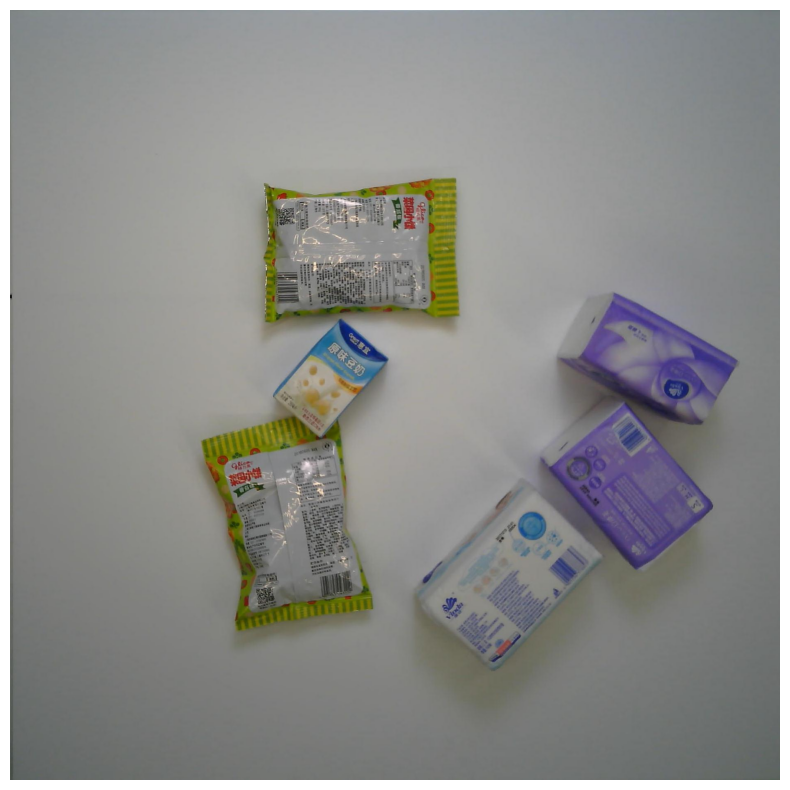

In [29]:
rpc_validation = load_dataset(
    "benjamintli/retail-product-checkout",
    split="validation",
    streaming=True
)

query_sample = None

for sample in rpc_validation:
    categories = set(map(int, sample["objects"]["category"]))
    matching = categories.intersection(selected_category_ids)

    if len(matching) >= 2:
        query_sample = sample
        print("Ground-truth indexed SKUs present:", sorted(matching))
        break

if query_sample is None:
    raise RuntimeError("No suitable RPC validation image was found.")

shelf_image = query_sample["image"].convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(shelf_image)
plt.axis("off")
plt.show()

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Ground-truth indexed SKUs present: [1, 176, 187]


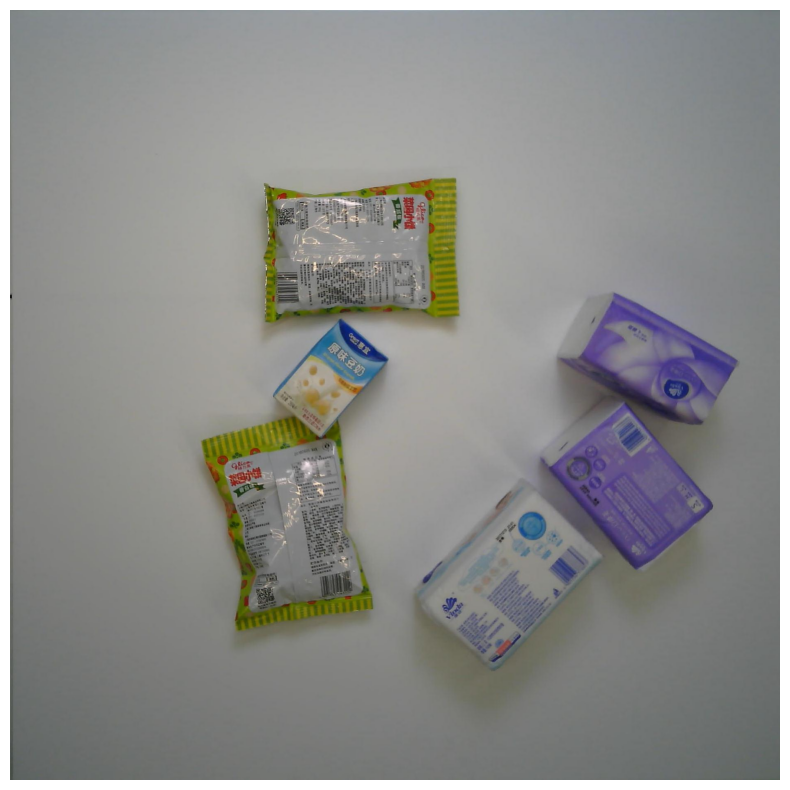

In [30]:
rpc_validation = load_dataset(
    "benjamintli/retail-product-checkout",
    split="validation",
    streaming=True
)

query_sample = None

for sample in rpc_validation:
    categories = set(map(int, sample["objects"]["category"]))
    matching = categories.intersection(selected_category_ids)

    if len(matching) >= 2:
        query_sample = sample
        print("Ground-truth indexed SKUs present:", sorted(matching))
        break

if query_sample is None:
    raise RuntimeError("No suitable RPC validation image was found.")

shelf_image = query_sample["image"].convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(shelf_image)
plt.axis("off")
plt.show()

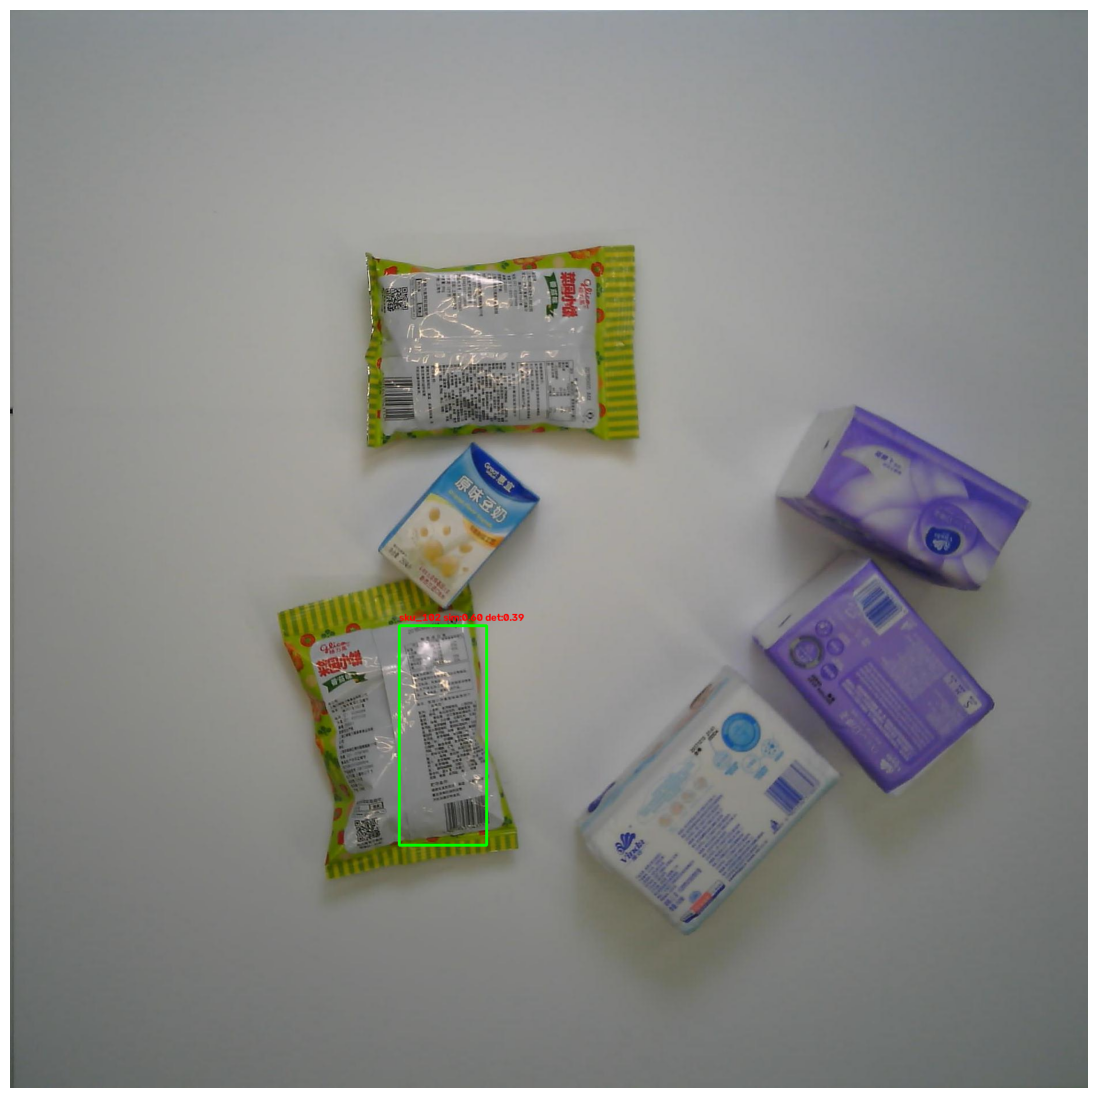

Detected products: 1
Saved to: /content/drive/MyDrive/ShelfSense/combined_pipeline_result.jpg


In [31]:
detection = detector.predict(
    source=shelf_image,
    imgsz=640,
    conf=0.25,
    iou=0.7,
    max_det=1000,
    device=0,
    verbose=False
)[0]

annotated = np.array(shelf_image).copy()

for box, detection_confidence in zip(
    detection.boxes.xyxy.cpu().numpy(),
    detection.boxes.conf.cpu().numpy()
):
    x1, y1, x2, y2 = map(int, box)

    crop = shelf_image.crop((x1, y1, x2, y2))
    input_tensor = preprocess(crop).unsqueeze(0).to(device)

    with torch.inference_mode():
        query_embedding = embedding_model(input_tensor)
        query_embedding = F.normalize(
            query_embedding, p=2, dim=1
        ).cpu().numpy().astype("float32")

    # Retrieve five nearest reference crops
    similarities, indices = faiss_index.search(
        query_embedding, 5
    )

    votes = defaultdict(list)

    for similarity, index in zip(
        similarities[0], indices[0]
    ):
        sku_id = sku_mapping[str(int(index))]["sku_id"]
        votes[sku_id].append(float(similarity))

    # Majority vote, then highest average similarity
    predicted_sku = max(
        votes,
        key=lambda sku: (
            len(votes[sku]),
            np.mean(votes[sku])
        )
    )

    similarity = max(votes[predicted_sku])

    label = (
        f"{predicted_sku} "
        f"sim:{similarity:.2f} "
        f"det:{detection_confidence:.2f}"
    )

    cv2.rectangle(
        annotated, (x1, y1), (x2, y2),
        (0, 255, 0), 3
    )

    cv2.putText(
        annotated,
        label,
        (x1, max(25, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

output_path = (
    "/content/drive/MyDrive/ShelfSense/"
    "combined_pipeline_result.jpg"
)

cv2.imwrite(
    output_path,
    cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
)

plt.figure(figsize=(14, 14))
plt.imshow(annotated)
plt.axis("off")
plt.show()

print("Detected products:", len(detection.boxes))
print("Saved to:", output_path)

In [32]:
from ultralytics import YOLO
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import json

output_root = Path("/content/drive/MyDrive/ShelfSense")

# Export YOLOv12 detector
detector = YOLO(
    output_root /
    "yolov12m_sku110k_final/weights/best.pt"
)

detector.export(
    format="onnx",
    imgsz=640,
    opset=17,
    simplify=True,
    dynamic=True
)

Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon 2.00GHz)
YOLOv12m summary (fused): 402 layers, 19,577,299 parameters, 0 gradients, 59.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (37.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 225.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 272.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 46.7 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 25.8s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: export failure ❌ 26.1s: No module named

ModuleNotFoundError: No module named 'onnxscript'

In [33]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 13.1 MB/s eta 0:00:00


In [34]:
from ultralytics import YOLO
from pathlib import Path
import shutil

output_root = Path("/content/drive/MyDrive/ShelfSense")

detector = YOLO(
    output_root /
    "yolov12m_sku110k_final/weights/best.pt"
)

exported_path = detector.export(
    format="onnx",
    imgsz=640,
    opset=17,
    simplify=True,
    dynamic=True
)

final_detector_path = output_root / "yolov12m_sku110k.onnx"

shutil.copy2(exported_path, final_detector_path)

print("Detector exported to:", final_detector_path)

Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon 2.00GHz)
YOLOv12m summary (fused): 402 layers, 19,577,299 parameters, 0 gradients, 59.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (37.9 MB)

ONNX: starting export with onnx 1.22.0 opset 17...


W0913 18:32:50.481000 943 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line

ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 33.0s, saved as '/content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.onnx' (74.8 MB)

Export complete (42.1s)
Results saved to /content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/drive/MyDrive/ShelfSense/yolov12m_sku110k_final/weights/best.onnx imgsz=640 data=/content/sku110k.yaml  
Visualize:       https://netron.app
Detector exported to: /content/drive/MyDrive/ShelfSense/yolov12m_sku110k.onnx


In [35]:
class NormalizedEmbeddingModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, image):
        embedding = self.backbone(image)
        return F.normalize(embedding, p=2, dim=1)

deployment_embedding_model = NormalizedEmbeddingModel(
    embedding_model
).to(device).eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    deployment_embedding_model,
    dummy_input,
    output_root / "mobilenetv3_embedding.onnx",
    input_names=["image"],
    output_names=["embedding"],
    dynamic_axes={
        "image": {0: "batch"},
        "embedding": {0: "batch"}
    },
    opset_version=17,
    do_constant_folding=True
)

preprocessing_config = {
    "input_size": [224, 224],
    "color_format": "RGB",
    "pixel_scale": "0_to_1",
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "embedding_dimension": 960,
    "normalization": "L2"
}

with open(output_root / "embedding_preprocessing.json", "w") as file:
    json.dump(preprocessing_config, file, indent=4)

print("Export completed")

W0913 18:34:57.284000 943 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `NormalizedEmbeddingModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `NormalizedEmbeddingModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: 

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Export completed


In [36]:
import onnx

onnx_path = output_root / "mobilenetv3_embedding.onnx"

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)

print("Valid ONNX model")
print("ONNX opset:", onnx_model.opset_import[0].version)
print("Saved at:", onnx_path)

Valid ONNX model
ONNX opset: 18
Saved at: /content/drive/MyDrive/ShelfSense/mobilenetv3_embedding.onnx


In [37]:
from pathlib import Path
import shutil

drive_root = Path("/content/drive/MyDrive/ShelfSense")
bundle = drive_root / "ShelfSense_Codex_Bundle"
bundle.mkdir(parents=True, exist_ok=True)

files = {
    # Main models
    drive_root / "yolov12m_sku110k_final/weights/best.pt":
        bundle / "best.pt",

    drive_root / "yolov12m_sku110k.onnx":
        bundle / "yolov12m_sku110k.onnx",

    drive_root / "mobilenetv3_embedding.onnx":
        bundle / "mobilenetv3_embedding.onnx",

    # Recognition files
    drive_root / "sku_index.faiss":
        bundle / "sku_index.faiss",

    drive_root / "sku_mapping.json":
        bundle / "sku_mapping.json",

    drive_root / "embedding_preprocessing.json":
        bundle / "embedding_preprocessing.json",

    # Training information
    drive_root / "yolov12m_sku110k_final/args.yaml":
        bundle / "training_config.yaml",

    drive_root / "yolov12m_sku110k_final/results.csv":
        bundle / "training_metrics.csv",

    drive_root / "test_evaluation/test_metrics.json":
        bundle / "test_metrics.json"
}

copied = []
missing = []

for source, destination in files.items():
    if source.exists():
        shutil.copy2(source, destination)
        copied.append(destination.name)
    else:
        missing.append(str(source))

print("Copied files:")
for filename in copied:
    print(" -", filename)

if missing:
    print("\nMissing optional files:")
    for filename in missing:
        print(" -", filename)

# Create downloadable ZIP
zip_path = shutil.make_archive(
    str(drive_root / "ShelfSense_Codex_Bundle"),
    "zip",
    root_dir=bundle
)

print("\nBundle folder:", bundle)
print("ZIP file:", zip_path)

Copied files:
 - best.pt
 - yolov12m_sku110k.onnx
 - mobilenetv3_embedding.onnx
 - sku_index.faiss
 - sku_mapping.json
 - embedding_preprocessing.json
 - training_config.yaml
 - training_metrics.csv
 - test_metrics.json

Bundle folder: /content/drive/MyDrive/ShelfSense/ShelfSense_Codex_Bundle
ZIP file: /content/drive/MyDrive/ShelfSense/ShelfSense_Codex_Bundle.zip


In [38]:
from pathlib import Path
import shutil

drive_root = Path("/content/drive/MyDrive/ShelfSense")
bundle = drive_root / "ShelfSense_Codex_Bundle"

artifacts_dir = bundle / "artifacts" / "colab"
references_dir = bundle / "data" / "references"

artifacts_dir.mkdir(parents=True, exist_ok=True)
references_dir.mkdir(parents=True, exist_ok=True)

# Locate and copy MobileNet ONNX files, including external weights
mobilenet_files = list(
    drive_root.rglob("mobilenetv3_embedding.onnx*")
)

print("MobileNet files found:")

for source in mobilenet_files:
    print(" -", source)
    shutil.copy2(source, artifacts_dir / source.name)

# Copy complete reference-product catalogue
reference_source = drive_root / "reference_products_rpc"

shutil.copytree(
    reference_source,
    references_dir,
    dirs_exist_ok=True
)

print("\nReference catalogue copied.")

# Locate the Colab notebook
notebooks = list(
    Path("/content/drive/MyDrive").rglob("*.ipynb")
)

print("\nNotebooks found:")

for notebook in notebooks:
    print(" -", notebook)

MobileNet files found:
 - /content/drive/MyDrive/ShelfSense/mobilenetv3_embedding.onnx.data
 - /content/drive/MyDrive/ShelfSense/mobilenetv3_embedding.onnx
 - /content/drive/MyDrive/ShelfSense/ShelfSense_Codex_Bundle/mobilenetv3_embedding.onnx

Reference catalogue copied.

Notebooks found:
 - /content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
 - /content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
